## Data Aggrigation

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_train = pd.read_csv('drugsComTrain_raw.csv')
df_test = pd.read_csv('drugsComTest_raw.csv')

In [4]:
data = pd.concat([df_train,df_test])

In [5]:
data.sample(5)

,uniqueID,drugName,condition,review,rating,date,usefulCount
41021,97636,Nitroglycerin,Heart Attack,"""My dad is in the last stages of congestive he...",10,26-Sep-13,8
29431,224114,Budesonide,"Ulcerative Colitis, Active","""I was excited when I 1st heard about Uceris&#...",2,21-Mar-13,66
131513,94897,Abilify,Depression,"""At first I thought this medication was great....",3,1-Sep-10,25
32588,218147,Amoxicillin / clavulanate,Sinusitis,"""Took Augmentin for sinus and ear infection . ...",1,1-Dec-16,10
138042,18629,Tikosyn,Arrhythmia,"""I was diagnosed with chronic A-Fib about thre...",9,10-Mar-15,35


In [6]:
df = data.copy()

In [7]:
df.sample(10)

,uniqueID,drugName,condition,review,rating,date,usefulCount
75725,49346,Ethinyl estradiol / levonorgestrel,Polycystic Ovary Syndrome,"""Two weeks after beginning Seasonique, I began...",1,8-Feb-16,3
100714,15221,Ethinyl estradiol / norethindrone,Birth Control,"""My doctor told me to take this birth control ...",5,7-Jun-17,2
90937,42196,Dexilant,Barrett's Esophagus,"""I had mild Barrett&#039;s esophagus and was o...",10,19-May-14,44
72341,230393,Meloxicam,Osteoarthritis,"""Ohhhh what a relief like a miracle am worried...",10,25-Oct-15,39
159017,154095,Lialda,Ulcerative Colitis,"""took Lialda and was fine for 3 months. No ble...",8,12-Mar-16,3
24613,188555,ParaGard,Birth Control,"""The insertion was crampy but it only took a f...",9,23-Aug-16,4
90841,13142,Xolair,Urticaria,"""This has been a miracle for me, and I truly h...",8,14-May-14,67
34487,8733,Votrient,Soft Tissue Sarcoma,"""Hi everyone , I&#039;m 39 years old guy from ...",8,1-Mar-16,32
25120,190185,Ortho Tri-Cyclen Lo,Birth Control,"""I&#039;m just about finished my first pack of...",10,20-Jun-17,1
25476,80689,Tussionex Pennkinetic,Cough,"""I coughed horribly for a year and a half. Ha...",10,19-Sep-10,15


From initial observation, I can say that condition and review column consists of invalid char so it need to be cleaned

## Basic anaysis

In [8]:
df.shape

(215063, 7)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 215063 entries, 0 to 53765
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   uniqueID     215063 non-null  int64 
 1   drugName     215063 non-null  object
 2   condition    213869 non-null  object
 3   review       215063 non-null  object
 4   rating       215063 non-null  int64 
 5   date         215063 non-null  object
 6   usefulCount  215063 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 13.1+ MB


Data column is in string format. It need to be converted into date format

In [10]:
df.describe()

,uniqueID,rating,usefulCount
count,215063.000000,215063.000000,215063.000000
mean,116039.364814,6.990008,28.001004
std,67007.913366,3.275554,36.346069
min,0.000000,1.000000,0.000000
25%,58115.500000,5.000000,6.000000
50%,115867.000000,8.000000,16.000000
75%,173963.500000,10.000000,36.000000
max,232291.000000,10.000000,1291.000000


In [11]:
df.isnull().sum()

uniqueID          0
drugName          0
condition      1194
review            0
rating            0
date              0
usefulCount       0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

There are 1194 rows are null values in condition column

In [13]:
df.corr(numeric_only=True)

,uniqueID,rating,usefulCount
uniqueID,1.000000,0.016336,0.017567
rating,0.016336,1.000000,0.234860
usefulCount,0.017567,0.234860,1.000000


## Univariate analysis

In [14]:
from wordcloud import WordCloud, STOPWORDS

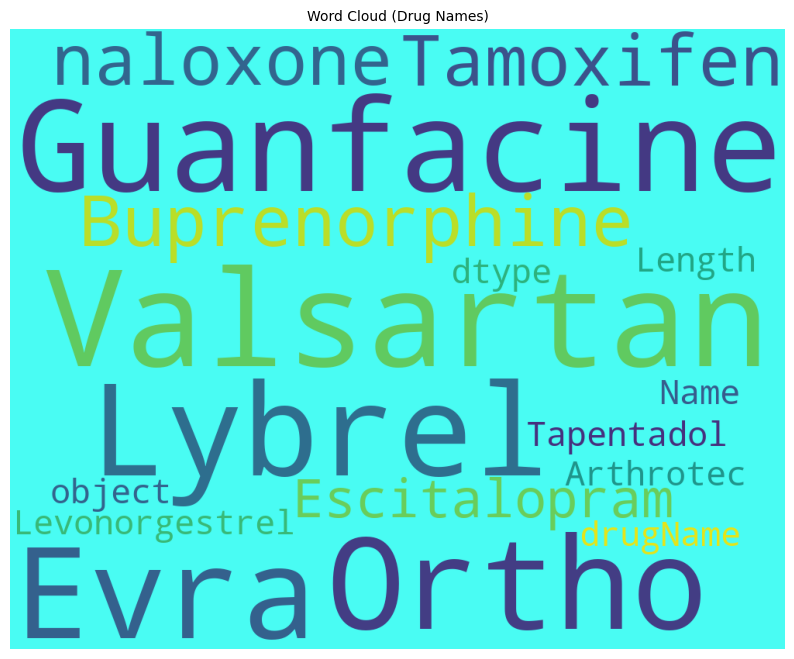

In [15]:
wordcloud = WordCloud(stopwords=set(STOPWORDS),
                      background_color='rgb(73, 252, 243)',
                      height=800,
                      width=1000
).generate(str(df['drugName']))


plt.figure(figsize=(10,10))
plt.title('Word Cloud (Drug Names)', fontsize = 10)
plt.axis("off")
plt.imshow(wordcloud)

The above cloud includes the metadata as well like dtype, Length etc. Because the str(pd.Series) includes meta data as well

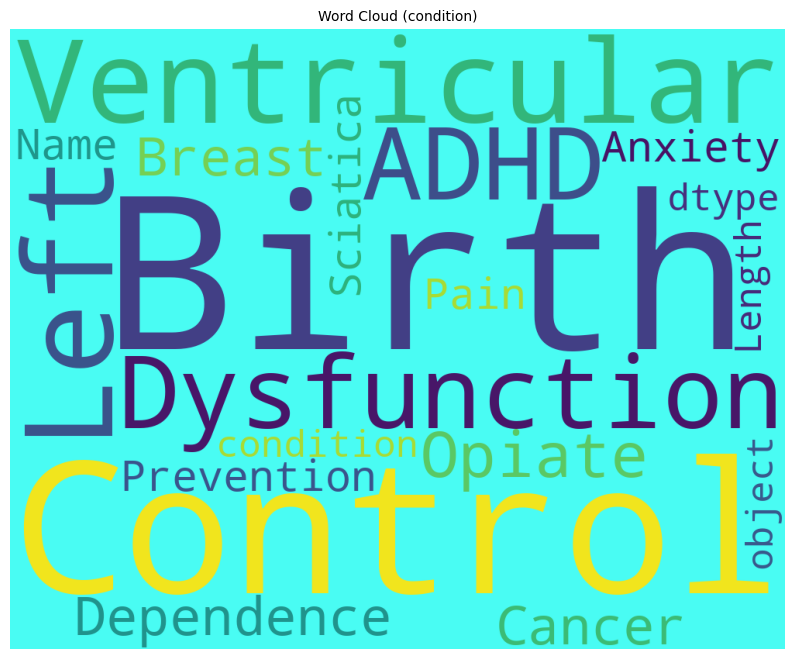

In [16]:
wordcloud = WordCloud(stopwords=set(STOPWORDS),
                      background_color='rgb(73, 252, 243)',
                      height=800,
                      width=1000
).generate(str(df['condition']))


plt.figure(figsize=(10,10))
plt.title('Word Cloud (condition)', fontsize = 10)
plt.axis("off")
plt.imshow(wordcloud)

Most of the times, we can see the birth control, ADHD, Ventricular etc

<Axes: ylabel='count'>

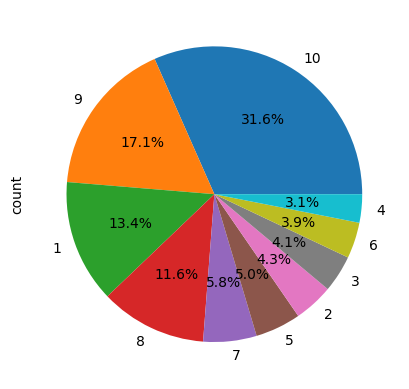

In [17]:
df['rating'].value_counts().plot(kind='pie',autopct='%1.1f%%')

<Axes: xlabel='rating', ylabel='Density'>

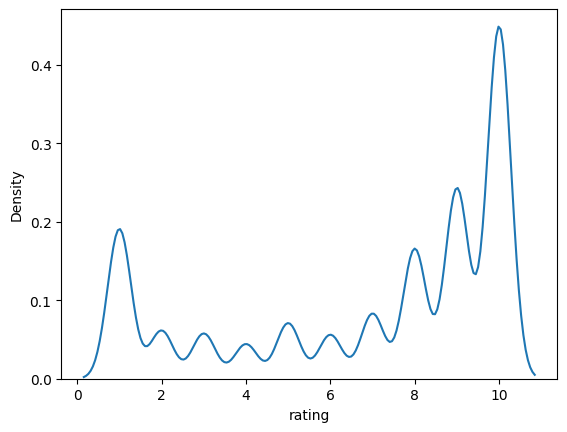

In [18]:
sns.kdeplot(df['rating'])

Most of the ratings are higher ratings ie 10, 9, 8. Some drugs about 13% also got worst rating 1

In [19]:
print((df['rating'] > 5).sum())
print((df['rating'] <= 5).sum())

150768
64295


Data is imbalance by a huge difference. May be the data includes so much of positive drugs. Hence the model may not perform well on negative drugs so well

## Bivariante analysis

C:\Users\91939\AppData\Local\Temp\ipykernel_3548\3663489246.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bar.set_xticklabels(bar.get_xticklabels(), rotation=90, ha='right')


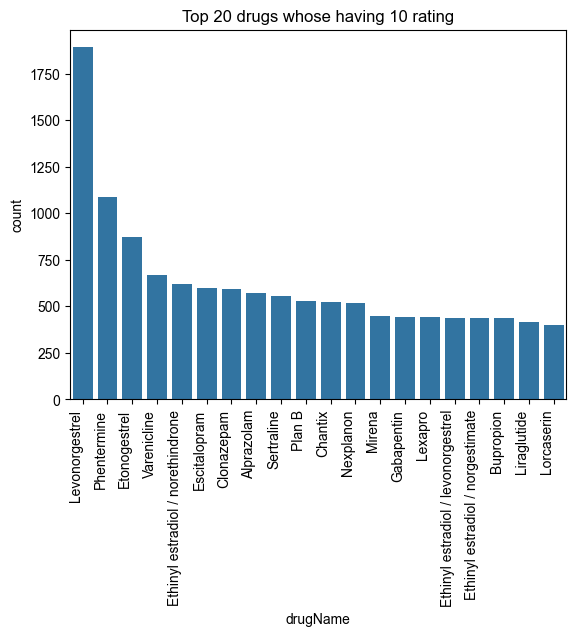

In [20]:
top_drugs_10 = df[df['rating'] == 10]['drugName'].value_counts().head(20)
bar=sns.barplot(top_drugs_10)
bar.set_title('Top 20 drugs whose having 10 rating')
bar.set_xticklabels(bar.get_xticklabels(), rotation=90, ha='right')
sns.set(style = 'darkgrid', font_scale = 1.3)
plt.rcParams['figure.figsize'] = [17, 5]

C:\Users\91939\AppData\Local\Temp\ipykernel_3548\1902578690.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bar.set_xticklabels(bar.get_xticklabels(), rotation=90, ha='right')


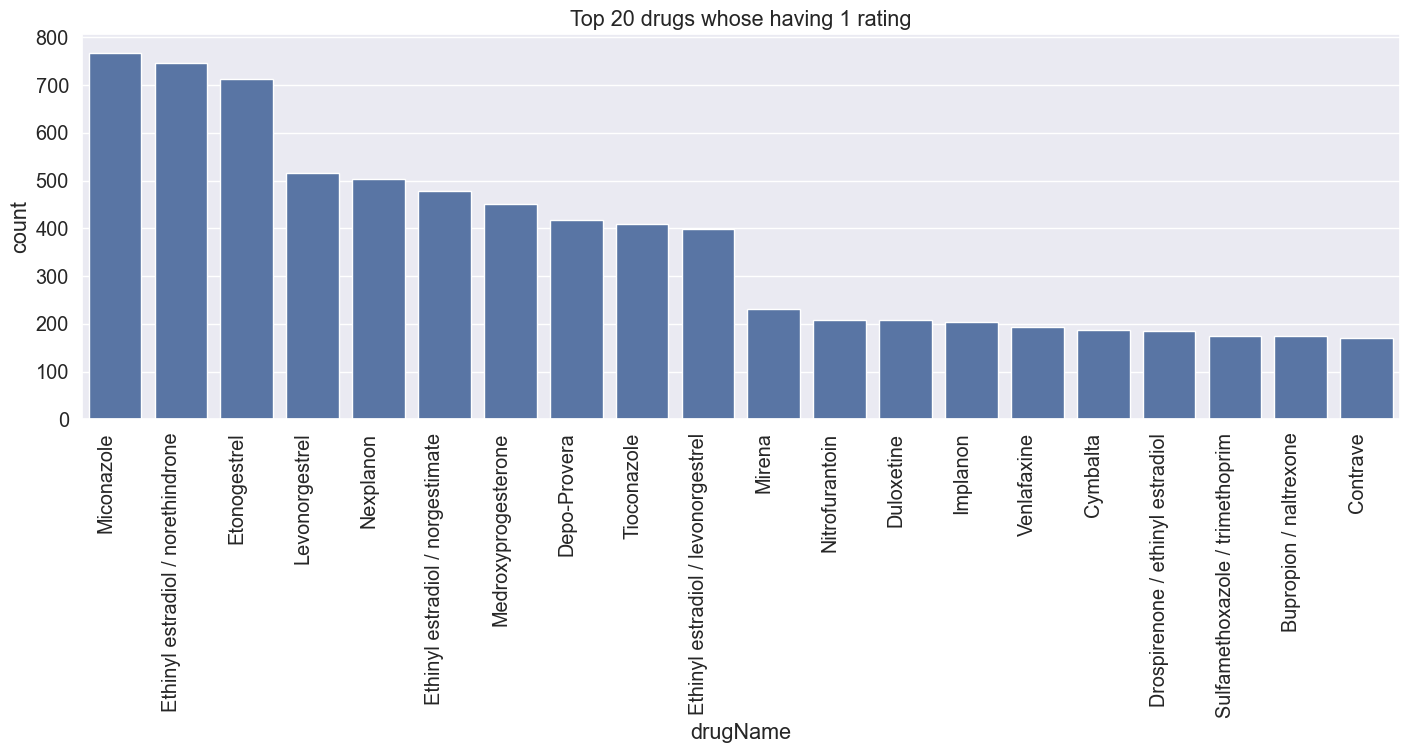

In [21]:
top_drugs_1 = df[df['rating'] == 1]['drugName'].value_counts().head(20)
bar=sns.barplot(top_drugs_1)
bar.set_title('Top 20 drugs whose having 1 rating')
bar.set_xticklabels(bar.get_xticklabels(), rotation=90, ha='right')
sns.set(style = 'darkgrid', font_scale = 1.3)
plt.rcParams['figure.figsize'] = [8, 8]

C:\Users\91939\AppData\Local\Temp\ipykernel_3548\4106974381.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bar.set_xticklabels(bar.get_xticklabels(), rotation=90, ha='right')


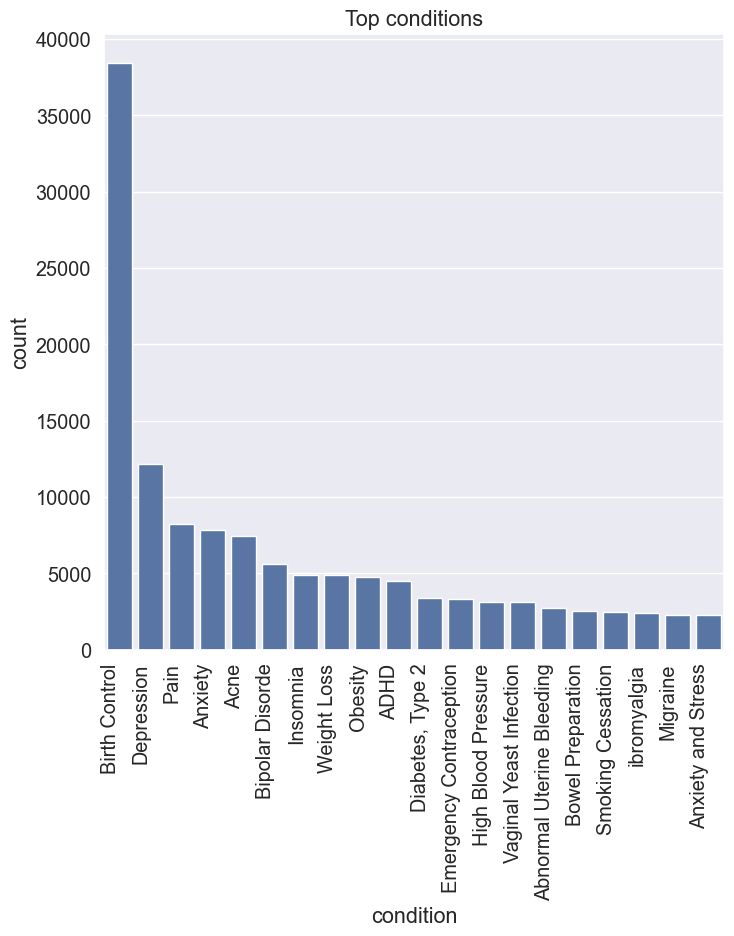

In [22]:
top_conditions = df['condition'].value_counts().head(20)
bar=sns.barplot(top_conditions)
bar.set_title('Top conditions')
bar.set_xticklabels(bar.get_xticklabels(), rotation=90, ha='right')
sns.set(style = 'darkgrid', font_scale = 1.3)
plt.rcParams['figure.figsize'] = [5, 5]

### visualizing as per date

In [23]:
df['date'] = pd.to_datetime(df['date'])

C:\Users\91939\AppData\Local\Temp\ipykernel_3548\3532345252.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'])


In [24]:
df['year']=df['date'].dt.year
df['month']=df['date'].dt.month
df['day']=df['date'].dt.day

In [25]:
df.head(2)

,uniqueID,drugName,condition,review,rating,date,usefulCount,year,month,day
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20,27,2012,5,20
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27,192,2010,4,27


Text(0.5, 1.0, 'Mean rating in a year')

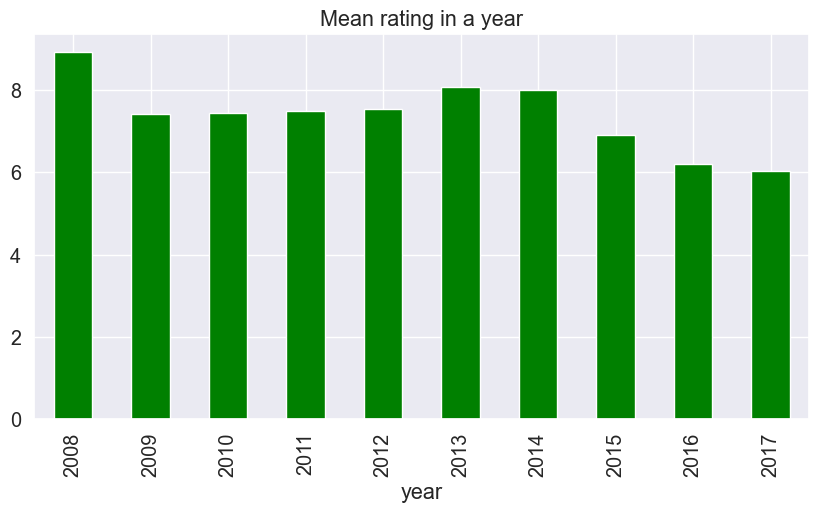

In [26]:
rating=df.groupby('year')['rating'].mean()
rating.plot(kind='bar',figsize=(10,5),color='green')
plt.title('Mean rating in a year')

Text(0.5, 1.0, 'Mean rating in a month')

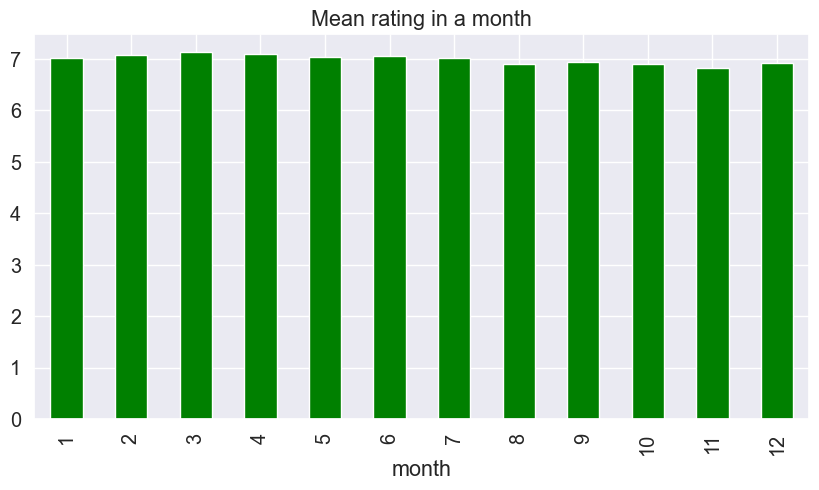

In [27]:
rating=df.groupby('month')['rating'].mean()
rating.plot(kind='bar',figsize=(10,5),color='green')
plt.title('Mean rating in a month')

Text(0.5, 1.0, 'Mean rating in a day')

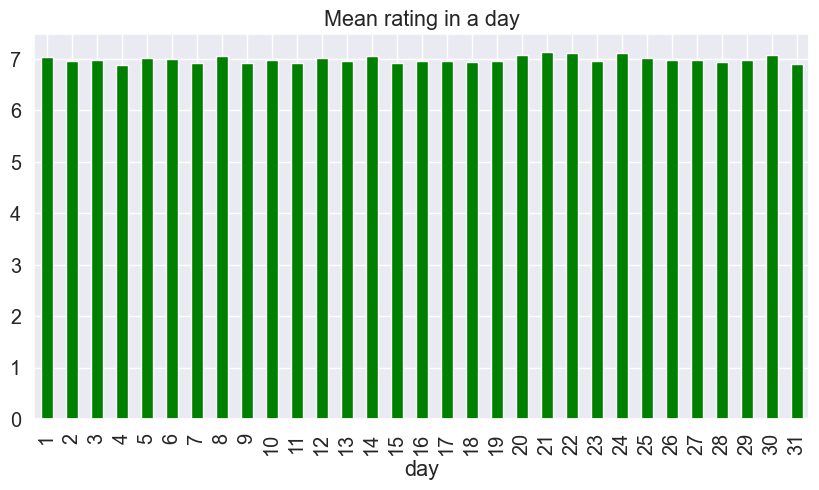

In [28]:
rating=df.groupby('day')['rating'].mean()
rating.plot(kind='bar',figsize=(10,5),color='green')
plt.title('Mean rating in a day')

As we seen the data is distributed equally across the year, month and day. So no need of date column

### Usefull count visualization

In [29]:
df["usefulCount"].describe()

count    215063.000000
mean         28.001004
std          36.346069
min           0.000000
25%           6.000000
50%          16.000000
75%          36.000000
max        1291.000000
Name: usefulCount, dtype: float64

As we see the stdev is so high and the data distribution is so large. So normalizing it will helpfull

In [30]:
df['usefulCount'].nunique()

397

C:\Users\91939\AppData\Local\Temp\ipykernel_3548\2665249276.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["usefulCount"],color="green")


Text(0.5, 1.0, 'Distribution of usefulCount')

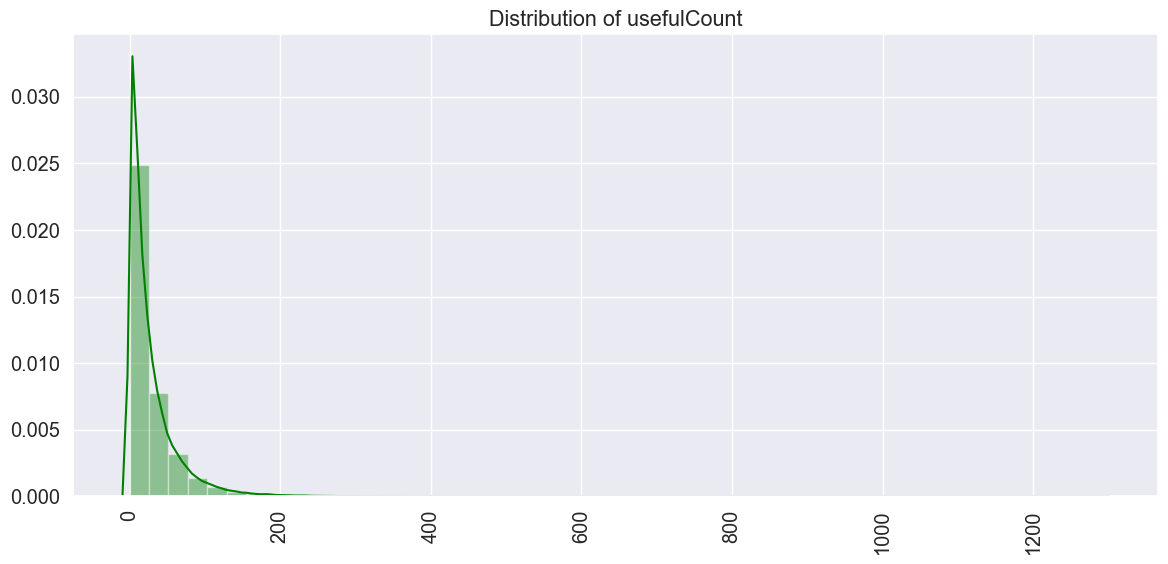

In [31]:
plt.figure(figsize=(14,6))
sns.distplot(df["usefulCount"],color="green")
plt.xticks(rotation='vertical')
plt.xlabel('', fontsize=12)
plt.ylabel('', fontsize=12)
plt.title("Distribution of usefulCount")

## Text preprocessing

#### Droping null values

In [32]:
df=df.dropna(how="any", axis=0)

In [33]:
import re
def process(text):
    cleaned_text = re.sub(re.compile('<.*?>'), '', text) #removes html tags
    cleaned_text = cleaned_text.lower() #lowers the data
    cleaned_text = cleaned_text.replace(r'[^\w\d\s]',' ') #removes the special characters
    cleaned_text = cleaned_text.replace(r'[^\x00-\x7F]+',' ') # remove all non aschi values
    cleaned_text = cleaned_text.strip() #removes trailing and leading spaces
    cleaned_text = cleaned_text.replace(r'\s+',' ') # replace multiple spaces with single one
    cleaned_text = cleaned_text.replace(r'\.{2,}', ' ') # replace multiple . with single
    cleaned_text = cleaned_text.replace("&#039;", "") #remove repeating pattern
    
    return cleaned_text

### condition series preprocessing

In [34]:
df['condition'] = df['condition'].apply(process)

In [35]:
df['review'] = df['review'].apply(process)

In [36]:
df.sample(20)

,uniqueID,drugName,condition,review,rating,date,usefulCount,year,month,day
16396,201499,Zoloft,depression,"""zoloft. you made me realize, ive been locked ...",9,2014-03-20,207,2014,3,20
128815,161438,Diphenhydramine,insomnia,"""awoke with banging headache similar to a whis...",2,2016-08-01,4,2016,8,1
11466,68873,Medroxyprogesterone,amenorrhea,"""i am 25 and unfortunately have always had irr...",10,2016-07-31,19,2016,7,31
112304,125898,Viibryd,depression,"""i think it has made me extremely tired and it...",2,2015-10-03,17,2015,10,3
2318,5678,Oxytrol,overactive bladde,"""i had very bad experience with ditropan (oxyb...",9,2010-09-10,55,2010,9,10
91316,93546,Famotidine,urticaria,"""while i found this awesome and it got rid of ...",5,2017-02-02,3,2017,2,2
143672,115022,Diazepam,anxiety,"""diazepam is ok in the very short term but is...",6,2015-10-08,20,2015,10,8
157481,119910,Losartan,high blood pressure,"""lisinopril gave me bad cough and sinus draini...",10,2015-09-12,47,2015,9,12
90833,176080,Famvir,cold sores,"""it worked great for me. 1500mg in one shot, t...",10,2009-01-11,25,2009,1,11
13198,206070,Interferon beta-1a,multiple sclerosis,"""i have been taking rebif - i see an improveme...",8,2011-01-27,20,2011,1,27


After doing the preprocessing, in some reviews we find \r, \n and emojis and @amp for and . So remove them also

In [37]:
emoji_pattern = re.compile(
    "["
    u"\U0001F600-\U0001F64F"
    u"\U0001F300-\U0001F5FF"
    u"\U0001F680-\U0001F6FF"
    u"\U0001F1E0-\U0001F1FF"
    "]+",
    flags=re.UNICODE,
)

In [38]:
df['review'] = (df['review'].str.replace(r'[\n\r]+', ' ', regex=True).str.replace(emoji_pattern, '', regex=True))

In [39]:
df['review'] = df['review'].str.replace('&amp;', 'and', regex=True)
df['review'] = df['review'].str.replace('&quot;', 'and', regex=True)

In [40]:
df.sample(20)

,uniqueID,drugName,condition,review,rating,date,usefulCount,year,month,day
130160,10651,Spironolactone,heart failure,"""having heart failure(e/f 20%) and edema and n...",8,2010-09-21,48,2010,9,21
35086,99270,Trezix,pain,"""didnt like the caffeine addition of this medi...",7,2012-09-06,11,2012,9,6
24662,161908,Aquoral,xerostomia,"""i only tried a sample and not very good tasti...",1,2017-02-20,1,2017,2,20
33268,91381,Anastrozole,breast cance,"""hello, i was diagnosed may 7,2016, had a sing...",1,2017-03-16,20,2017,3,16
128132,72755,Ethinyl estradiol / norethindrone,birth control,"""well ive been on this birth control for a mon...",6,2015-09-03,4,2015,9,3
158685,45594,Fluoxetine,anxiety and stress,"""i had mild ocd, mdd, stress, anxiety since ch...",1,2012-06-18,2,2012,6,18
13375,1643,Eluxadoline,irritable bowel syndrome,"""took 1 dose and landed in the hospital with s...",1,2016-04-23,29,2016,4,23
132289,67184,Magnesium hydroxide,constipation,"""warning. once you have your first bowel movem...",10,2015-03-19,81,2015,3,19
55532,210142,Linzess,irritable bowel syndrome,"""so far loving this. stomach pain has almost d...",8,2016-07-21,17,2016,7,21
34696,43146,Sronyx,birth control,"""i went on this pill after being on the nuvari...",2,2014-06-29,7,2014,6,29


Now the review and conditions looks good

## Feature Engineering

In [41]:
df.drop(columns=['date','year','month','day','uniqueID'],inplace=True)

In [42]:
df.sample()

,drugName,condition,review,rating,usefulCount
32979,Lantus,"diabetes, type 2","""diabetes, type 1 with insulin resistance. i u...",10,6


In [43]:
df['sentiment'] = df["rating"].apply(lambda x: 1 if x > 5 else 0)

In [44]:
df.sample(5)

,drugName,condition,review,rating,usefulCount,sentiment
149165,Nitrofurantoin,urinary tract infection,"""also want to say, most people are likely to c...",10,17,1
66003,Desvenlafaxine,depression,"""i have been on pristiq for about 2 months. iv...",10,235,1
75623,Contrave,obesity,"""i have been on contrave for 1 month for 2 con...",10,21,1
95975,Imipramine,panic disorde,"""this medication saved my life! ive only been ...",10,15,1
67333,Fioricet,headache,"""i just took this medicine for the first time,...",10,47,1


#### Feature representation

In [45]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\91939\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [46]:
from nltk.corpus import stopwords

sw_list = stopwords.words('english')
df['review'] = df['review'].apply(lambda x: [item for item in x.split() if item not in sw_list]).apply(lambda x:" ".join(x))

In [47]:
df.sample(5)

,drugName,condition,review,rating,usefulCount,sentiment
50015,Diclofenac,pain,"""i tendonitis wrists years repetitive movement...",7,1,1
74250,Imuran,systemic lupus erythematosus,"""worked fantastic systemic lupus erythematosus...",10,47,1
45007,Caziant,birth control,"""let preface saying taken many different kinds...",10,3,1
35410,Ampyra,multiple sclerosis,"""ampyra miracle me. one pill day exactly one m...",10,28,1
53719,Savella,ibromyalgia,"""i fibromyalgia 10 years tried almost everythi...",1,36,0


In [48]:
df.loc[df['condition'] == '0 users found this comment helpful.'].shape

(128, 6)

In [49]:
df['condition'] = df['condition'].str.replace('0 users found this comment helpful.', 'Not Specified', regex=True)

In [50]:
df.loc[df['condition'] == 'Not Specified'].head(3)

,drugName,condition,review,rating,usefulCount,sentiment
516,Nortrel 1 / 35,Not Specified,"""they switched necon nortrel saying andsameand...",2,0,0
553,Loestrin 24 Fe,Not Specified,"""i loestrin 24 fe 6 months never problems emot...",7,0,1
571,Ortho Tri-Cyclen Lo,Not Specified,"""i love birth control spotting periods. little...",9,0,1


In [51]:
!pip install textblob

Defaulting to user installation because normal site-packages is not writeable


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
from nltk.stem import SnowballStemmer
from textblob import TextBlob

In [53]:
Snow_ball = SnowballStemmer("english")
df['review'] = df['review'].apply(lambda x: " ".join(Snow_ball.stem(word) for word in x.split()))

In [54]:
df.sample(3)

,drugName,condition,review,rating,usefulCount,sentiment
146341,Crestor,high cholesterol,"""mi doctor switch lipitor crestor get incred l...",9,76,1
40182,Tapentadol,pain,"""i put medic taken hydromorphone. horrible! gi...",1,37,0
127405,Ethinyl estradiol / norgestimate,birth control,"""i read review start take relat much....al thi...",8,4,1


In [55]:
# to determine the polarity of the review
def sentiment(review):
    pol = []
    for i in review:
        analysis = TextBlob(i)
        pol.append(analysis.sentiment.polarity)
    return pol

In [56]:
df['review_sentiment'] = sentiment(df['review'])

In [57]:
df.sample(10)

,drugName,condition,review,rating,usefulCount,sentiment,review_sentiment
50251,Acetaminophen / codeine,pain,"""i prescrib tylenol codein gallston act up. we...",1,3,0,0.281250
113964,Pregabalin,peripheral neuropathy,"""mi husband multipl myeloma patient took prega...",2,8,0,0.062500
155974,Metronidazole,dental abscess,"""terribl 3 day poor throw sick, short breath, ...",1,16,0,-0.371429
160664,Acetazolamide,pseudotumor cerebri,"""i diagnos idiopath intracrani hypertens earli...",10,82,1,0.333333
157591,Levora,birth control,"""it job, obviously--i havent pregnant. mood sw...",6,47,1,-0.263333
157676,Topiramate,obesity,"""hi reea want updat guy progress thus far medi...",7,47,1,0.006667
137506,Cymbalta,depression,"""i take cymbalta depress almost month. notic c...",7,22,1,0.363889
148498,Belviq,weight loss,"""90 day update. 245 213. head south 200. xxl s...",10,135,1,0.348148
3050,Pemoline,adhd,"""wish still available. miss abl function like ...",10,4,1,-0.031481
108738,Cialis,erectile dysfunction,"""mi husband tri last night. wow, amaz lasts.""",10,19,1,0.050000


In [58]:
df.corr(numeric_only=True)

,rating,usefulCount,sentiment,review_sentiment
rating,1.000000,0.235121,0.916406,0.287993
usefulCount,0.235121,1.000000,0.212763,0.073422
sentiment,0.916406,0.212763,1.000000,0.261538
review_sentiment,0.287993,0.073422,0.261538,1.000000


In [59]:
import nltk
nltk.download('punkt_tab')
from nltk import sent_tokenize
import gensim
from gensim.utils import simple_preprocess

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\91939\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [60]:
df['rev_tokens'] = df['review'].apply(simple_preprocess)
df['con_tokens'] = df['condition'].apply(simple_preprocess)

In [61]:
from gensim.models import Word2Vec

rev_sentences = df['rev_tokens'].tolist()
con_sentenses = df['con_tokens'].tolist()
corpus = rev_sentences + con_sentenses

w2v_model = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

In [62]:
w2v_model.train(corpus,total_examples=w2v_model.corpus_count,epochs=w2v_model.epochs)

(42792016, 48073060)

In [63]:
def vectorize(text):
    tokens = text.split()
    vectors = [w2v_model.wv[word] for word in tokens if word in w2v_model.wv]
    if not vectors:
        return np.zeros(w2v_model.vector_size)
    return np.mean(vectors, axis=0)

In [64]:
df['condition_vector'] = df['condition'].apply(vectorize)

In [65]:
df['condition_vector'].iloc[0]

array([ 0.68257934, -0.33097562, -1.4418964 ,  1.5470963 ,  1.4598659 ,
       -0.49661386, -0.23006713,  0.6435512 ,  0.385391  , -0.5196895 ,
        0.2354693 ,  0.34022227, -0.9182458 , -0.44795713,  0.49760246,
       -0.253649  ,  0.4113103 , -0.13788521,  0.764833  , -0.42705044,
       -0.9518321 , -0.01564892, -0.5101192 ,  0.19779037,  0.7845904 ,
       -0.8486695 , -0.71541023, -0.30057153, -0.10353283, -1.6445665 ,
        1.7308124 , -0.41287556, -0.20855832,  0.22730626,  1.9184753 ,
        1.0050879 , -0.01184372, -0.28385112, -0.04389741, -1.1228051 ,
       -0.62542987,  0.09045545,  0.48370424, -0.19526498, -0.55485415,
       -0.2577881 ,  0.53055257,  0.5620488 , -0.22392868,  0.6597569 ,
        0.29796624,  0.64395505, -1.4484233 , -0.01950085, -1.3215804 ,
        1.1701773 , -0.42209306, -0.83663297, -0.3070388 ,  0.42162576,
        1.6647531 , -0.23650332,  1.0136195 ,  0.15619038, -0.5044675 ,
        0.05299662,  0.2680582 ,  0.471733  ,  0.63086396,  2.26

In [66]:
df['review_vector'] = df['review'].apply(vectorize)

In [67]:
df['review_vector'].iloc[0]

array([ 0.7405486 ,  0.01261073,  0.8991247 ,  0.29139218,  0.33338735,
       -0.05006456,  0.5680696 , -0.19439244, -0.70239997, -1.5194329 ,
        0.9589351 ,  0.04109323,  0.09859776,  0.20195067, -0.36906585,
        0.54379785, -1.412558  , -0.41592693, -0.5623313 ,  0.4605939 ,
        0.4293425 ,  0.71333855,  1.4192463 , -0.6341805 ,  0.9694824 ,
        1.4822911 , -0.00624923, -0.39961138,  0.39479828, -0.56169647,
       -0.45809117, -0.3173196 , -0.9675321 ,  0.11531343,  0.27058938,
        0.49434248, -0.3870872 ,  0.3444551 ,  0.49988082, -1.0116079 ,
       -0.69602203, -0.31792057, -1.4050194 , -0.20544155,  0.46723437,
       -0.15702526, -0.15979086, -0.16379516,  0.06065017,  0.19056958,
        0.01388798,  0.30296537,  0.32176173,  0.5467757 ,  1.5722026 ,
        0.89201576,  0.00818934, -0.46731344, -0.6274416 ,  0.36146364,
       -0.21727616,  0.7170977 ,  0.71606463,  0.52195376, -0.40850282,
        0.8853218 , -1.0196513 ,  0.21039927,  0.41138944, -0.30

In [68]:
df.sample()

,drugName,condition,review,rating,usefulCount,sentiment,review_sentiment,rev_tokens,con_tokens,condition_vector,review_vector
9524,Clonidine,adhd,"""mi son 6 year old diagnos adhd, odd, asperg s...",4,20,0,0.02381,"[mi, son, year, old, diagnos, adhd, odd, asper...",[adhd],"[-0.431916, -4.9593906, 3.656636, -4.533089, -...","[0.6955843, -0.14808816, 0.5386517, -0.6227875..."


In [69]:
df.drop(columns=['rev_tokens','con_tokens'],inplace=True)

In [70]:
df.sample()

,drugName,condition,review,rating,usefulCount,sentiment,review_sentiment,condition_vector,review_vector
10715,Zoloft,anxiety and stress,"""start work realli well two months. receiv low...",10,74,1,0.266667,"[0.35505006, -1.442799, -0.11075822, -1.807964...","[0.51166666, -0.5025874, 0.78981835, -0.363803..."


In [71]:
grouped = df.groupby(['condition', 'drugName']).agg({
    'review_vector': lambda x: np.mean(np.vstack(x), axis=0),
    'condition_vector': 'first',
    'review_sentiment': ['mean', 'std'],
    'rating': ['mean', 'count'],
    'usefulCount': 'sum'
}).reset_index()

In [72]:
grouped.columns = [
    'condition',
    'drugName',
    'review_vector',
    'condition_vector',
    'mean_sentiment',
    'std_sentiment',
    'mean_rating',
    'review_count',
    'useful_sum'
]

In [73]:
X_review = np.vstack(grouped['review_vector'].values)
X_condition = np.vstack(grouped['condition_vector'].values)

X_numeric = grouped[['mean_sentiment',
                     'std_sentiment',
                     'mean_rating',
                     'review_count',
                     'useful_sum']].values


In [74]:
cond_dim = X_condition.shape[1]
rev_dim = X_review.shape[1]

cond_cols = [f'cond_emb_{i}' for i in range(cond_dim)]
rev_cols  = [f'rev_emb_{i}' for i in range(rev_dim)]

num_cols = [
    'mean_sentiment',
    'std_sentiment',
    'mean_rating',
    'review_count',
    'useful_sum'
]
columns = cond_cols + rev_cols + num_cols

In [75]:
X = np.hstack([X_condition, X_review, X_numeric])

In [93]:
X_df = pd.DataFrame(X, columns=columns)

In [77]:
X_df.sample(5)

,cond_emb_0,cond_emb_1,cond_emb_2,cond_emb_3,cond_emb_4,cond_emb_5,cond_emb_6,cond_emb_7,cond_emb_8,cond_emb_9,...,rev_emb_95,rev_emb_96,rev_emb_97,rev_emb_98,rev_emb_99,mean_sentiment,std_sentiment,mean_rating,review_count,useful_sum
8659,0.181945,0.533523,0.684645,0.768564,1.036752,-0.449372,0.094815,1.385857,0.386867,1.423778,...,0.745588,0.086540,-0.665548,-0.221340,0.230653,0.000000,NaN,7.000000,1.0,10.0
845,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.437803,-0.042642,-0.061854,0.613401,-0.869286,0.311111,NaN,10.000000,1.0,0.0
6587,0.112359,-1.208251,-0.339115,0.582992,1.421998,0.487928,1.443792,-0.648464,-1.053284,-0.998106,...,0.314962,-0.247367,-0.036044,0.254807,-0.070676,-0.109184,NaN,5.000000,1.0,4.0
7170,-0.452119,1.532161,-1.619541,0.308773,2.739029,1.115547,-3.747192,1.037116,-0.727856,2.946369,...,-0.076410,0.131162,-0.053504,1.040473,-0.137752,0.050000,0.106066,10.000000,2.0,15.0
6907,0.275597,0.700143,-0.678703,0.242286,0.599319,-0.078165,0.118935,0.560807,-0.874814,0.544867,...,0.738269,-0.312685,-0.715331,0.486639,0.111554,0.019643,0.092717,6.714286,7.0,63.0


In [94]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, r2_score, classification_report

In [95]:
le = LabelEncoder()

In [96]:
y = le.fit_transform(grouped['drugName'])

In [97]:
X_train,X_test,Y_train,Y_test = train_test_split(X_df,y,test_size=0.2,random_state=42)

In [83]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    n_jobs=-1,
    random_state=42
)

In [84]:
rf.fit(X_train,Y_train)

RandomForestClassifier(max_depth=15, n_jobs=-1, random_state=42)

In [85]:
pred = rf.predict(X_test)

In [86]:
accuracy_score(Y_test,pred)

0.010582010582010581

In [100]:
from xgboost import XGBClassifier

model = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    num_class=len(np.unique(y)),
    tree_method='hist'
)

model.fit(X_train, Y_train)

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [   0    1    2 ... 3268 3269 3270], got [   1    2    3 ... 3664 3665 3666]

In [92]:
print(np.unique(y)[:10])
print(np.unique(y)[-10:])
print(min(y), max(y))

[0 1 2 3 4 5 6 7 8 9]
[3657 3658 3659 3660 3661 3662 3663 3664 3665 3666]
0 3666
